# 1. Data Preparation

## Load Data

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지: 운영체제별 기본 한글 폰트 지정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

TODAY = pd.to_datetime('2017-02-28')
df_all = pd.read_csv("../../data/processed/integrated_data.csv")


In [2]:
import easydict

args = easydict.EasyDict()
args.seed = 42
args.target = df_all['is_churn']

### 클래스 비율 확인

In [3]:
# 클래스 비율
df_all['is_churn'].value_counts()
df_all['is_churn'].value_counts() / df_all.shape[0]

# 전체 평균 이탈률: 모든 그래프의 비교 기준선
OVERALL = df_all["is_churn"].mean()  
print(f"전체 이탈률: {OVERALL:.2%}")

전체 이탈률: 8.95%


# 2. Feature Engineering

## Member Features

In [4]:
member_cols = ['city', 'bd', 'registered_via', 'registration_init_time']
df_all['has_member'] = (~df_all[member_cols].isna().all(axis=1)).astype(int)
#msno는있지만 다른 정보가 없는사람과 있는사람을 구분하는 컬럼
df_all['has_member'].value_counts()

has_member
1    88648
0    11352
Name: count, dtype: int64

#### registration_init_time

In [5]:
df_all['registration_init_time']= df_all['registration_init_time'].astype('Int64')

In [6]:
df_all['registration_init_time'] = pd.to_datetime(
    df_all['registration_init_time'].astype(str),
    format='%Y%m%d',     # 연4·월2·일2
    errors='coerce',     # 변환 불가 값은 에러 대신 NaN
)

reg = df_all['registration_init_time']
df_all['tenure_date'] = (TODAY- reg).dt.days  #가입 후 경과 일수


In [7]:
df_all['reg_year'] = reg.dt.year                            # 가입 연도

season_map = {3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름',
              9: '가을', 10: '가을', 11: '가을', 12: '겨울', 1: '겨울', 2: '겨울'}
df_all['reg_season'] = reg.dt.month.map(season_map)         # 결측은 NaN → 10단계에서 채움

# 같은 날 가입 인원. groupby는 결측 키를 기본으로 빼서, members 없는 사람은 NaN
df_all['same_join_day'] = df_all.groupby('registration_init_time')['msno'].transform('count')

#### gender

In [8]:
# 성별: 결측을 '미입력'이라는 하나의 그룹으로 취급
df_all["gender_status"] = df_all["gender"].fillna("미입력")
df_all["gender_status"].unique()

array(['female', '미입력', 'male'], dtype=object)

#### bd

In [9]:
# ── 4. 나이 정제 ──
bd = df_all['bd'].astype(float)
df_all['bd_clean'] = bd.where(bd.between(10, 80))           # 10~80세만 남기고 나머지 NaN
df_all['bd_isnan'] = df_all['bd_clean'].isna().astype(int)  # 나이 모름 = 1

# ── 5. 가입 당시 나이 ──
df_all['age_at_reg'] = df_all['bd_clean'] - df_all['tenure_date'] / 365

In [10]:
df_all["bd_bin"] = pd.cut( # 피쳐로 사용은 나중에
    df_all['bd_clean'],
    bins=[10, 20, 30, 40, 50, 60, np.inf],  # 60세 이상 전체를 포함하도록 np.inf 활용
    labels=["10대", "20대", "30대", "40대", "50대", "60대 이상"],
    right=False,  # 이상 ~ 미만 설정
)

#### city

In [11]:
# ── 6. 도시 ──
df_all['city_miss'] = (df_all['city'] == 1).astype(int)    # city 1(기본값 추정) = 1. NaN은 False → 0

city_int = df_all['city'].fillna(-1).astype(int)            # 결측 → -1 (members 없음)
city_counts = city_int.value_counts()
rare_cities = city_counts[city_counts < 500].index.difference([-1])   # 500명 미만 도시 (-1은 제외)
df_all['city_clean'] = city_int.where(~city_int.isin(rare_cities), 777)  # 희소 도시 → 777(기타)

# ── 7. 가입 경로 결측 ──
df_all['registered_via'] = df_all['registered_via'].fillna(-1).astype(int)   # 결측 → -1

# ── 9. 계절 결측 ──
df_all['reg_season'] = df_all['reg_season'].fillna('unknown')

# ── 10. 범주형 지정 ──
cat_cols = ['registered_via', 'city_clean', 'gender_status', 'reg_season']
df_all[cat_cols] = df_all[cat_cols].astype('category')

In [12]:
# 1. city 값별 사용자 수 및 비중 확인
city_summary = df_all.groupby('city').agg(
    cnt=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

city_summary['ratio'] = (city_summary['cnt'] / len(df_all) * 100).round(2)
print(city_summary.sort_values(by='cnt', ascending=False).head(10))

# 2. city가 1 인 유저들이 성별(gender)이나 나이(bd)도 미입력(NaN/0)인 경우가 많은지 교차 확인
print(df_all[df_all['city'] == 1]['gender_status'].value_counts(normalize=True))
print(df_all[df_all['city'] == 1]['bd_isnan'].value_counts(normalize=True)) 
# city가 1인데 성별 미입력 96퍼, 나이 미입력 97퍼

    city    cnt  churn_rate  ratio
0    1.0  45747    0.063982  45.75
11  13.0   9914    0.122655   9.91
3    5.0   7281    0.130889   7.28
2    4.0   4756    0.137931   4.76
13  15.0   4524    0.125553   4.52
20  22.0   4252    0.120179   4.25
4    6.0   2621    0.141167   2.62
12  14.0   2028    0.114892   2.03
10  12.0   1159    0.121657   1.16
7    9.0    992    0.122984   0.99
gender_status
미입력       0.968370
female    0.016416
male      0.015214
Name: proportion, dtype: float64
bd_isnan
1    0.974031
0    0.025969
Name: proportion, dtype: float64


## Transaction & Log Features

In [13]:
# ── 1. 가입 기간으로 나누기 ──
# 30일 미만은 30일로 올려서 나누기 폭주 방지. 가입정보 없으면 NaN

TRANS_START = pd.to_datetime('2015-01-01')
active_days = (TODAY - df_all['registration_init_time'].clip(lower=TRANS_START)).dt.days
active_years = active_days.clip(lower=30) / 365



df_all['trans_per_year']  = df_all['transaction_count'] / active_years   # 1년에 결제한 횟수
df_all['pay_per_year']    = df_all['total_payment'] / active_years       # 1년에 낸 금액
df_all['cancel_per_year'] = df_all['cancel_count'] / active_years        # 1년에 해지한 횟수


# ── 3. 데이터 유무 3부류 ──
df_all['data_group'] = np.select(
    [df_all['has_member'] == 0, df_all['has_log'] == 0],
    ['정보·로그 없음', '로그만 없음'],
    default='둘 다 있음',
)
df_all['data_group'] = df_all['data_group'].astype('category')

In [14]:
# 교차에 쓸 그룹 컬럼 (그래프용, 모델에는 안 넣음)
df_all['tenure_grp'] = pd.cut(df_all['tenure_date'],
                               bins=[-1, 365, 730, 1825, np.inf],
                               labels=['1년 미만', '1~2년', '2~5년', '5년 이상'])
df_all['age_grp'] = pd.cut(df_all['bd_clean'], bins=[9, 19, 29, 39, 80],
                            labels=['10대', '20대', '30대', '40대+'])

def age_log_diff(df, col):
    has_log = df['has_log'] == 1
    med = df[has_log].groupby('age_grp', observed=True)[col].median()   # 연령대별 중앙값
    diff = df[col] - df['age_grp'].map(med).astype(float)             # 내 값 - 내 연령대 중앙값
    return diff.where(has_log)                                         # 로그 없는 사람은 NaN

df_all['age_activity_diff'] = age_log_diff(df_all, 'activity_days')
df_all['age_secs_diff']     = age_log_diff(df_all, 'total_secs')


In [15]:
df_all.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'bd_bin', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'tenure_grp',
       'age_grp', 'age_activity_diff', 'age_secs_diff'],
      dtype='object')

In [16]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    'reg_season',
]

numbers = [
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',
    
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',
    
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',
    
    'trans_per_year', 'pay_per_year',
]

all_col = categories + numbers

## Merge Team Features

In [17]:

# H1. 최근 7일간 미이용 고객
df_all["inactive_7days"] = (
df_all["days_since_last_log"].gt(7) |
df_all["has_log"].eq(0)
).astype(int)

# H2. 청취시간 1시간당 완청 곡 수
listening_hours = df_all["total_secs"].replace(0, np.nan) / 3600

df_all["completed_per_hour"] = (
df_all["total_num_100"] / listening_hours
)

# H3. 과거 거래 취소 비율
tx_count = df_all["transaction_count"].replace(0, np.nan)

df_all["cancel_rate"] = (
df_all["cancel_count"] / tx_count
)

# H4. 자동 갱신 미사용 + 낮은 활동량
df_all["no_auto_renew_low_activity"] = (
    df_all["last_auto_renew"].eq(0) &
    df_all["activity_days"].le(5)
).astype(int)

# H5. 장기 가입 + 낮은 활동량
df_all["long_tenure_low_activity"] = (
    df_all["tenure_date"].ge(365) &
    df_all["activity_days"].le(5)
).astype(int)

In [18]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


def add_features(data):
    data = data.copy()

    # 0 값 자체가 의미를 가질 수 있는 보조 flag
    data["no_unique_song"] = (data["total_num_unq"] == 0).astype(int)
    data["zero_plan_days"] = (data["last_plan_days"] == 0).astype(int)

    data["avg_payment"] = safe_divide(
        data["total_payment"],
        data["transaction_count"]
    )

    # 이용 로그 관련
    data["avg_daily_secs"] = safe_divide(
        data["total_secs"],
        data["activity_days"]
    )

    data["avg_daily_complete"] = safe_divide(
        data["total_num_100"],
        data["activity_days"]
    )

    data["avg_daily_unq"] = safe_divide(
        data["total_num_unq"],
        data["activity_days"]
    )

    data["complete_per_unq"] = safe_divide(
        data["total_num_100"],
        data["total_num_unq"]
    )

    # 결제 효율 관련
    data["payment_per_plan_day"] = safe_divide(
        data["avg_payment"],
        data["last_plan_days"]
    )

    return data


df_all = add_features(df_all)


In [19]:
df_all.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'bd_bin', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'tenure_grp',
       'age_grp', 'age_activity_diff', 'age_secs_diff', 'inactive_7days',
       'completed_per_hour', 'cancel_rate', 'no_auto_renew_low_activity',
       'long_tenure_low_activity', 'no_unique_song', 'zero_plan_days',
       'avg_payment', 'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
       'complete_per_unq', 'payment_pe

# 3. Feature Selection & Data Split

In [20]:
base_members = ['registered_via', 'city_clean', 'gender_status']
team_base = ['transaction_count', 'cancel_count', 'total_payment',
             'last_auto_renew', 'last_is_cancel', 'last_plan_days',
             'cancel_on_last_date', 'has_transaction',          # days_to_expire 제외
             'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
             'days_since_last_log', 'has_log']

mine  = ['reg_season', 'has_member', 'tenure_date', 'same_join_day', 'bd_clean',
         'bd_isnan', 'age_at_reg', 'city_miss', 'trans_per_year', 'pay_per_year']
sohee = ['inactive_7days', 'completed_per_hour', 'cancel_rate',
         'no_auto_renew_low_activity', 'long_tenure_low_activity']
sunah = ['avg_payment', 'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
         'complete_per_unq', 'payment_per_plan_day', 'no_unique_song', 'zero_plan_days']

feature_sets = {
    '① 기본':        base_members + team_base,
    '② 기본 + 본인': base_members + team_base + mine,
    '③ 기본 + 소희': base_members + team_base + sohee,
    '④ 기본 + 선아': base_members + team_base + sunah,
    '⑤ 전체':        base_members + team_base + mine + sohee + sunah,
}

In [21]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    #'reg_season',
]

numbers = [
    # members (본인)
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',

    # 거래 (팀 통합)
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',

    # 로그 (팀 통합)
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',

    #members 결합 (본인)
    'trans_per_year', #'pay_per_year',

     # 소희 (제외 여부는 아래 '피처 조합 비교' 결과로 판단 → 결과표 아래 메모에 사유 기록)
     #'inactive_7days', 'completed_per_hour', 'cancel_rate',
     #'no_auto_renew_low_activity', 'long_tenure_low_activity',

    # # 선아
    'avg_payment', 
    'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
    'complete_per_unq', 'payment_per_plan_day',
    'no_unique_song', 'zero_plan_days',
]

all_col = categories + numbers
print(f"범주형 {len(categories)}개 + 수치형 {len(numbers)}개 = {len(all_col)}개")   # 현재 3 + 30 = 33개

범주형 3개 + 수치형 30개 = 33개


## Train/Test Split

In [22]:
from sklearn.model_selection import train_test_split

# 피처 조합 비교(ablation)에도 쓰도록 후보 컬럼 전체를 분할해 둔다
cand_cols = list(dict.fromkeys(all_col + [c for cols in feature_sets.values() for c in cols]))
cand_cats = [c for c in ['registered_via', 'city_clean', 'gender_status', 'reg_season'] if c in cand_cols]

# 인덱스로 분할 (같은 seed·stratify라 기존 분할과 동일한 행이 나뉨)
train_idx, test_idx = train_test_split(df_all.index, random_state=args.seed,
                                       test_size=0.2, stratify=df_all[targets])

# ── 분할 후 재계산: 테스트 데이터 정보가 피처에 섞이지 않도록 학습 데이터로만 계산 ──
# (1) same_join_day: 학습 데이터에서 같은 날 가입한 인원 수
join_cnt = df_all.loc[train_idx].groupby('registration_init_time')['msno'].count()
sjd = df_all['registration_init_time'].map(join_cnt)
df_all['same_join_day'] = sjd.where(df_all['registration_init_time'].isna(), sjd.fillna(0))  # 가입일 있는데 학습에 없는 날 → 0

# (2) city_clean: 희소 도시 기준을 학습 데이터로 (전체 10만 기준 500명 → 학습 8만 기준 400명)
city_int = df_all['city'].fillna(-1).astype(int)
city_cnt_tr = city_int.loc[train_idx].value_counts()
keep_cities = city_cnt_tr[city_cnt_tr >= 400].index.union([-1])
df_all['city_clean'] = city_int.where(city_int.isin(keep_cities), 777)   # 희소·미등장 도시 → 777(기타)

df_all[cand_cats] = df_all[cand_cats].astype('category')

feature = df_all[cand_cols]
target = df_all[targets]
x_train, x_test = feature.loc[train_idx], feature.loc[test_idx]
y_train, y_test = target.loc[train_idx], target.loc[test_idx]

x_train[all_col].shape, y_train.shape, x_test[all_col].shape, y_test.shape

((80000, 33), (80000,), (20000, 33), (20000,))

In [23]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

from common.models import ModelType
from common.evaluate import get_score, evaluate
from common.cross_validation import cv_compare, cv_evaluate, cv_feature_sets, fit_params_for
from common.parameter_tuning import CatObjective, LgbObjective, XgbObjective, run_study

c:\dev\project\2차 단위 프로젝트\2nd-feature-model-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feature Set Comparison

In [24]:
feature_sets_cmp = {**feature_sets, '⑥ 최종 선택(all_col)': all_col}
feature_cmp = cv_feature_sets("lgb", feature_sets_cmp, x_train, y_train, args.seed, cand_cats)
display(feature_cmp.round(4))

① 기본: 0.8611 (±0.0033)
② 기본 + 본인: 0.8661 (±0.0045)
③ 기본 + 소희: 0.8620 (±0.0035)
④ 기본 + 선아: 0.8636 (±0.0030)
⑤ 전체: 0.8701 (±0.0040)
⑥ 최종 선택(all_col): 0.8690 (±0.0036)


,피처 수,ROC-AUC 평균,표준편차,기본 대비
① 기본,17,0.8611,0.0033,0.0000
② 기본 + 본인,27,0.8661,0.0045,0.0050
③ 기본 + 소희,22,0.8620,0.0035,0.0009
④ 기본 + 선아,25,0.8636,0.0030,0.0026
⑤ 전체,40,0.8701,0.0040,0.0090
⑥ 최종 선택(all_col),33,0.8690,0.0036,0.0079


**피처 선택 결과 메모**
- 피처(inactive_7days 등 5개) 제외 사유: 기본 피처에 추가 시 ROC-AUC +0.0009로 교차검증 표준편차(±0.0035) 이내 → 성능 기여 없음. 대부분 기존 피처(days_since_last_log, cancel_count/transaction_count 등)에서 바로 계산되는 파생값이라 모델이 이미 학습 가능한 정보로 판단.
- reg_season, pay_per_year 제외 사유: 전체(⑤, 40개, 0.8701)와 최종 선택(⑥, 33개, 0.8690)의 차이가 0.0011로 표준편차(±0.004) 이내 → 제외해도 성능 차이 없음. 성능이 같으면 피처가 적은 모델이 해석·유지보수에 유리해 제외.

## Leakage Check

In [25]:
from sklearn.metrics import roc_auc_score

single_auc = {}
for c in numbers:
    v = x_train[c].astype(float)
    v = v.fillna(v.min() - 1)                       # 결측은 가장 작은 값으로 (AUC 계산용)
    a = roc_auc_score(y_train, v)
    single_auc[c] = max(a, 1 - a)                   # 방향과 무관하게 판별력만 본다
single_auc = pd.Series(single_auc).sort_values(ascending=False)
display(single_auc.head(10).round(4).to_frame('단일 피처 ROC-AUC'))

suspect = single_auc[single_auc >= 0.85]
print("⚠ 누수 의심 피처:" if len(suspect) else "단일 피처 ROC-AUC 0.85 이상 없음", list(suspect.index))

,단일 피처 ROC-AUC
last_auto_renew,0.7390
avg_payment,0.6824
transaction_count,0.6455
trans_per_year,0.6344
bd_isnan,0.6024
last_plan_days,0.5966
age_at_reg,0.5887
bd_clean,0.5811
city_miss,0.5717
avg_daily_unq,0.5474


단일 피처 ROC-AUC 0.85 이상 없음 []


# 4. Model Comparison & Tuning

## Baseline Cross-Validation

In [26]:
cv_default = cv_compare(["cat", "lgb", "xgb"], x_train[all_col], y_train, args.seed, categories)
display(cv_default.round(4))

cat 교차 검증 평균 점수: 0.8703 (±0.0036)
lgb 교차 검증 평균 점수: 0.8690 (±0.0036)
xgb 교차 검증 평균 점수: 0.8568 (±0.0039)


,cat,lgb,xgb
0,0.8695,0.8670,0.8547
1,0.8716,0.8707,0.8602
2,0.8705,0.8675,0.8552
3,0.8644,0.8648,0.8517
4,0.8754,0.8751,0.8623


## Hyperparameter Tuning

In [27]:
study_cat = run_study(
    CatObjective(x_train[all_col], y_train, args.seed, categories,
                 iterations=(200, 500), lr=(0.05, 0.2),
                 depth=(4, 7), l2=(1, 10)),
    args.seed, n_trials=15, timeout=600)

Best Score: 0.871254356139073
Best hp {'iterations': 400, 'learning_rate': 0.05332562317538384, 'depth': 6, 'l2_leaf_reg': 2.5347171131856236}


In [28]:
study_lgb = run_study(
    LgbObjective(x_train[all_col], y_train, args.seed,
                n_estimators=(100, 500), lr=(0.02, 0.2),
                num_leaves=(15, 63), min_child=(20, 100)),
    args.seed, n_trials=20, timeout=300)

Best Score: 0.872399958293055
Best hp {'n_estimators': 200, 'learning_rate': 0.02008331932698382, 'num_leaves': 53, 'min_child_samples': 41}


In [29]:
# study_xgb = run_study(
#     XgbObjective(x_train[all_col], y_train, args.seed,
#                  n_estimators=(300, 1000), lr=(0.01, 0.1),
#                  max_depth=(4, 8), min_child=(1, 10)),
#     args.seed, n_trials=20)

## Final Model Selection

In [ ]:
studies = {"cat": study_cat
           ,"lgb": study_lgb
           #,"xgb": study_xgb
           }

def check_boundary(name, study):
    """최적값이 탐색 범위 끝(양 끝 2% 이내)에 붙어 있으면 경고 → 범위를 더 넓혀야 함"""
    for p, d in study.best_trial.distributions.items():
        v = study.best_params[p]
        pos = (v - d.low) / (d.high - d.low) if d.high > d.low else 0.5
        if pos <= 0.02 or pos >= 0.98:
            print(f"⚠ {name}.{p} = {v} 가 탐색 범위 [{d.low}, {d.high}] 경계에 있음")

EVAL_SEED = args.seed + 1
rows, candidates = {}, {}
for name, study in studies.items():
    check_boundary(name, study)
    base  = cv_evaluate(name, x_train[all_col], y_train, EVAL_SEED, categories)
    tuned = cv_evaluate(name, x_train[all_col], y_train, EVAL_SEED, categories, **study.best_params)
    rows[name] = {"기본 설정": base.mean(), "튜닝 후": tuned.mean(),
                  "향상": tuned.mean() - base.mean(), "fold 표준편차": tuned.std()}
    candidates[(name, "기본")] = (base.mean(), {})
    candidates[(name, "튜닝")] = (tuned.mean(), study.best_params)

compare = pd.DataFrame(rows).T
display(compare.round(4))
print("※ '향상'이 fold 표준편차보다 작으면 튜닝 효과는 오차 범위 안")

⚠ lgb.learning_rate = 0.02008331932698382 가 탐색 범위 [0.02, 0.2] 경계에 있음


,기본 설정,튜닝 후,향상,fold 표준편차
cat,0.8689,0.8701,0.0011,0.0052
lgb,0.8692,0.8708,0.0016,0.0059


※ '향상'이 fold 표준편차보다 작으면 튜닝 효과는 오차 범위 안


# 5. Final Model Evaluation

## Test Scores & Confusion Matrix

In [31]:
# 기본/튜닝 설정 모두 후보로 두고 재평가 점수가 가장 높은 것을 선택
(best_name, best_kind), (best_cv, best_params) = max(candidates.items(), key=lambda kv: kv[1][0])
print(f"선택된 모델: {best_name} ({best_kind}, CV {best_cv:.4f}) / 적용 파라미터: {best_params}")

final_model = ModelType[best_name].create(args.seed, **best_params)
fit_params = fit_params_for(best_name, categories)
final_model.fit(x_train[all_col], y_train, **fit_params)

score = evaluate(final_model, [x_train[all_col], y_train], [x_test[all_col], y_test])
display(pd.DataFrame({
    k: {"ROC-AUC": s["auc_score"], "PR-AUC": s["pr_auc"]} for k, s in score.items()
}).T.round(4))

선택된 모델: lgb (튜닝, CV 0.8708) / 적용 파라미터: {'n_estimators': 200, 'learning_rate': 0.02008331932698382, 'num_leaves': 53, 'min_child_samples': 41}


,ROC-AUC,PR-AUC
train_score,0.9071,0.6756
test_score,0.8719,0.6116


In [32]:
import optuna
optuna.visualization.plot_param_importances(studies[best_name]).show()
optuna.visualization.plot_optimization_history(studies[best_name]).show()

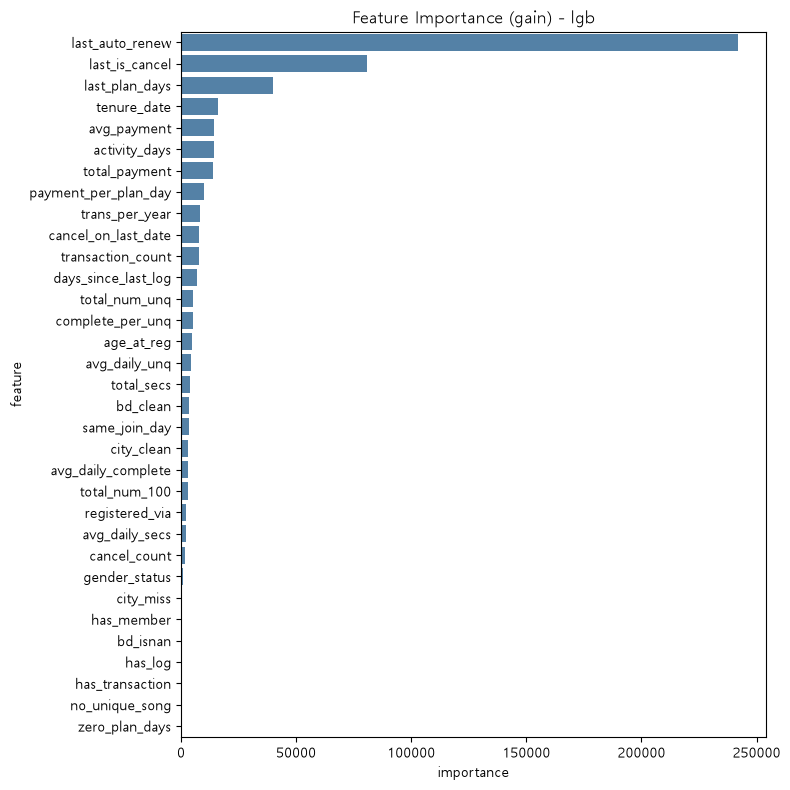

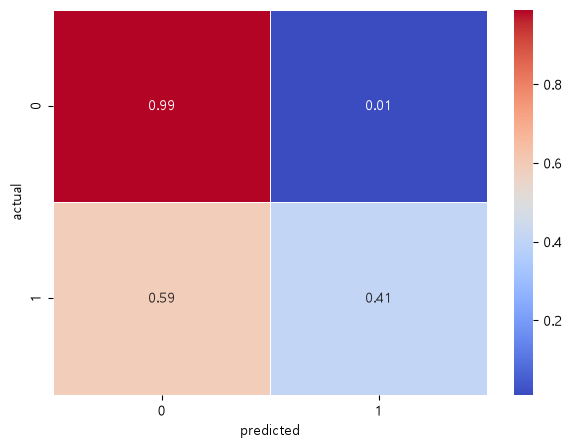

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     18210
           1       0.79      0.41      0.54      1790

    accuracy                           0.94     20000
   macro avg       0.87      0.70      0.75     20000
weighted avg       0.93      0.94      0.93     20000



In [33]:
# 피처 중요도 (최종 모델)
imp = pd.Series(
    final_model.feature_importances_,
    index=x_train[all_col].columns,
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=imp.values, y=imp.index, color='steelblue')
plt.title(f'Feature Importance (gain) - {best_name}')
plt.xlabel('importance')
plt.ylabel('feature')
plt.tight_layout()
plt.show()

# 혼동행렬 (테스트, 0.5 기준)
conf_mx = score['test_score']['conf_mx']

plt.figure(figsize=(7, 5))
sns.heatmap(conf_mx, annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

print(score['test_score']['report'])

## Threshold Tuning

In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=args.seed)
cv_model = ModelType[best_name].create(args.seed, **best_params)

proba_cv = cross_val_predict(cv_model, x_train[all_col], y_train, cv=skf,
                             method="predict_proba",
                             params=fit_params_for(best_name, categories))[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, proba_cv)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best = f1[:-1].argmax()
TH = thresholds[best]
print(f"기준선: {TH:.3f} (재현율 {recall[best]:.3f}, 정밀도 {precision[best]:.3f})")

기준선: 0.282 (재현율 0.531, 정밀도 0.633)


              precision    recall  f1-score   support

           0       0.96      0.97      0.96     18210
           1       0.63      0.54      0.58      1790

    accuracy                           0.93     20000
   macro avg       0.79      0.75      0.77     20000
weighted avg       0.93      0.93      0.93     20000



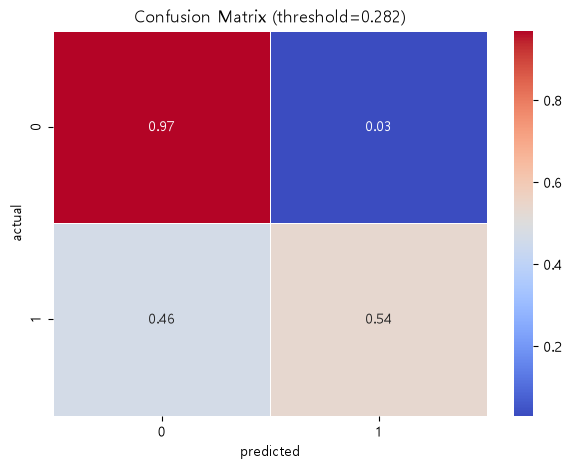

In [35]:
test_th = get_score(final_model, x_test[all_col], y_test, threshold=TH)
print(test_th['report'])

plt.figure(figsize=(7, 5))
sns.heatmap(test_th['conf_mx'], annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title(f'Confusion Matrix (threshold={TH:.3f})')
plt.show()

In [42]:
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

proba_te = final_model.predict_proba(x_test[all_col])[:, 1]
summary = pd.DataFrame({
    f"기준선 {t:.3f}": {
        "ROC-AUC": roc_auc_score(y_test, proba_te),
        "PR-AUC": average_precision_score(y_test, proba_te),
        "정밀도": precision_score(y_test, proba_te >= t),
        "재현율": recall_score(y_test, proba_te >= t),
        "F1": f1_score(y_test, proba_te >= t),
    } for t in [0.5, TH]
}).T
display(summary.round(4))

,ROC-AUC,PR-AUC,정밀도,재현율,F1
기준선 0.500,0.8719,0.6116,0.7895,0.4106,0.5402
기준선 0.282,0.8719,0.6116,0.6328,0.5363,0.5806


# 6. Model Interpretation (SHAP)

In [37]:
import shap

X_te = x_test[all_col]

# 학습된 모델을 넣는다
explainer = shap.TreeExplainer(final_model)
# 학습된 모델을 갖고 X_te를 예측
shap_values = explainer.shap_values(X_te)

shap_values.shape, X_te.shape

c:\dev\project\2차 단위 프로젝트\2nd-feature-model-ml\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


((20000, 33), (20000, 33))

In [38]:
X_plot = X_te.copy()
for c in categories:
    X_plot[c] = X_plot[c].cat.codes

In [39]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0, :], X_plot.iloc[0, :])

c:\dev\project\2차 단위 프로젝트\2nd-feature-model-ml\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


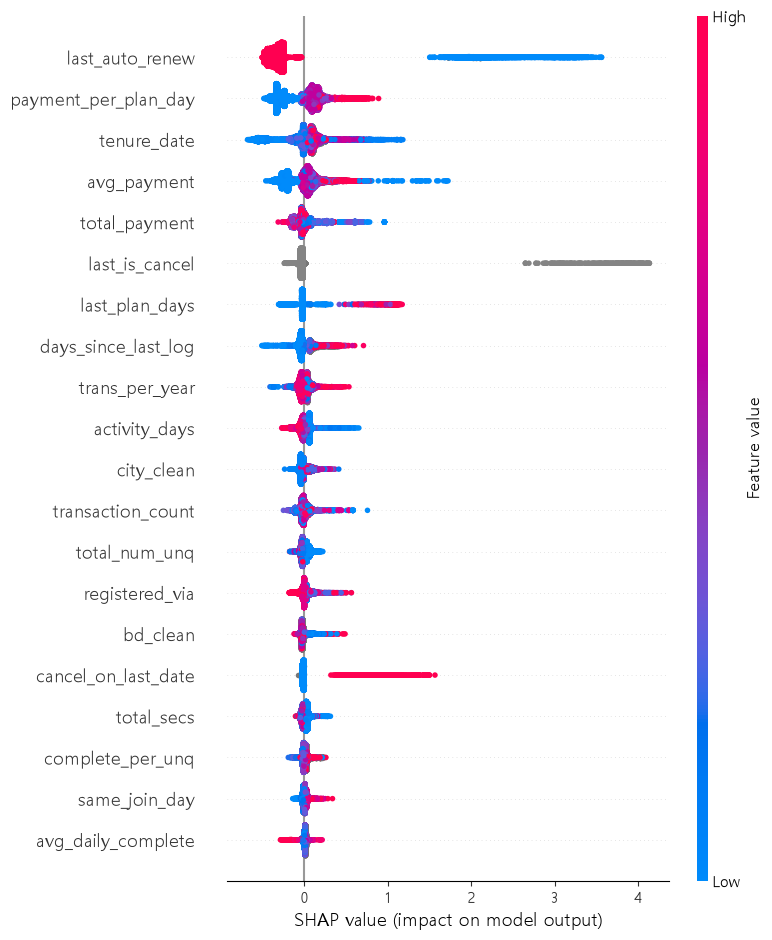

In [40]:

X_te = x_test[all_col]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_te)

# 그래프용: 범주형을 숫자 코드로
X_plot = X_te.copy()
for c in categories:
    X_plot[c] = X_plot[c].cat.codes

shap.summary_plot(shap_values, X_plot)

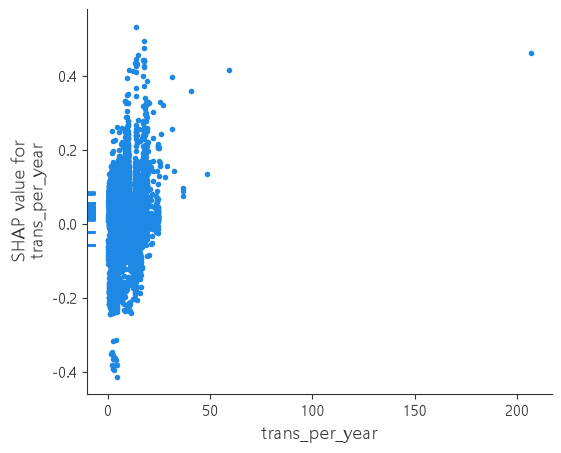

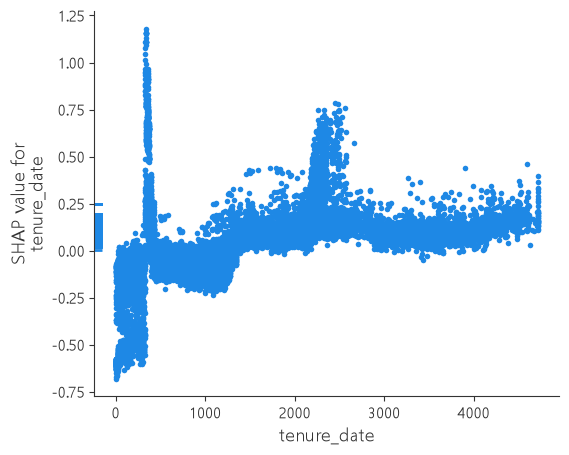

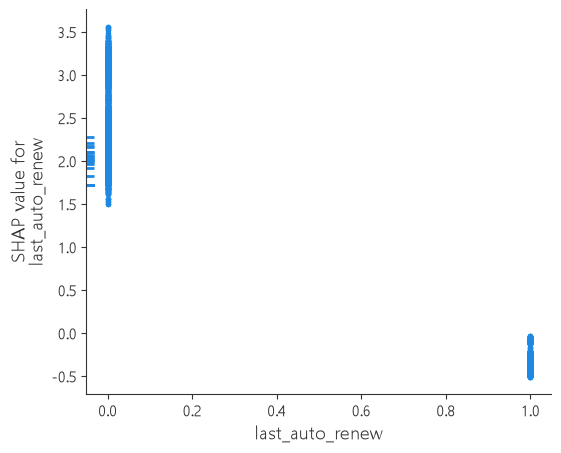

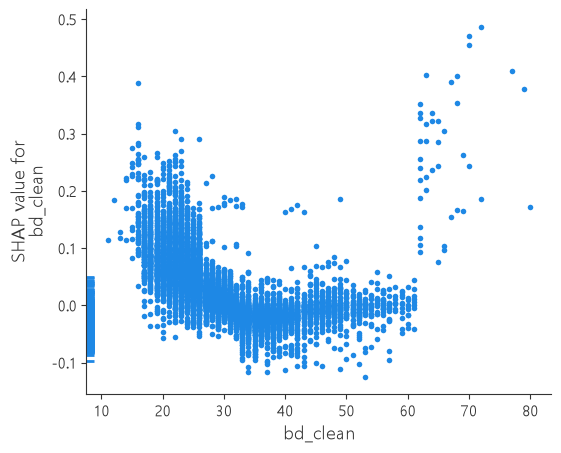

In [41]:
for col in ["trans_per_year", "tenure_date", "last_auto_renew", "bd_clean"]:
    shap.dependence_plot(col, shap_values, X_plot, interaction_index=None)